# PARcast 
### ***Land Station Data***

In [3]:
# Import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load the data
df = pd.read_csv('/Users/loriberberian/Desktop/bioSCape/PARcast/data_processing/data/raw/LPAR/B_LPAR_20260401_0001.CSV', 
                 parse_dates=['datetime'])

# Quick look at the data
df.head(10)

,datetime,raw_counts,millivolts,ppfd_umol_m2_s
0,2026-04-01 17:11:04,0,0.0000,0.00
1,2026-04-01 17:11:05,0,0.0000,0.00
2,2026-04-01 17:11:06,0,0.0000,0.00
3,2026-04-01 17:11:07,1,0.0078,0.78
4,2026-04-01 17:11:08,1,0.0078,0.78
5,2026-04-01 17:11:09,0,0.0000,0.00
6,2026-04-01 17:11:10,0,0.0000,0.00
7,2026-04-01 17:11:11,1,0.0078,0.78
8,2026-04-01 17:11:12,0,0.0000,0.00
9,2026-04-01 17:11:13,0,0.0000,0.00


In [5]:
# Basic summary statistics
df.describe()

,datetime,raw_counts,millivolts,ppfd_umol_m2_s
count,906,906.000000,906.000000,906.000000
mean,2026-04-01 17:18:43.232891,149.873068,1.170877,117.087748
min,2026-04-01 17:11:04,-1.000000,-0.007800,-0.780000
25%,2026-04-01 17:14:53.250000,0.000000,0.000000,0.000000
50%,2026-04-01 17:18:43.500000,1.000000,0.007800,0.780000
75%,2026-04-01 17:22:32.750000,3.000000,0.023400,2.340000
max,2026-04-01 17:26:22,862.000000,6.734400,673.440000
std,NaN,317.745133,2.482390,248.238979


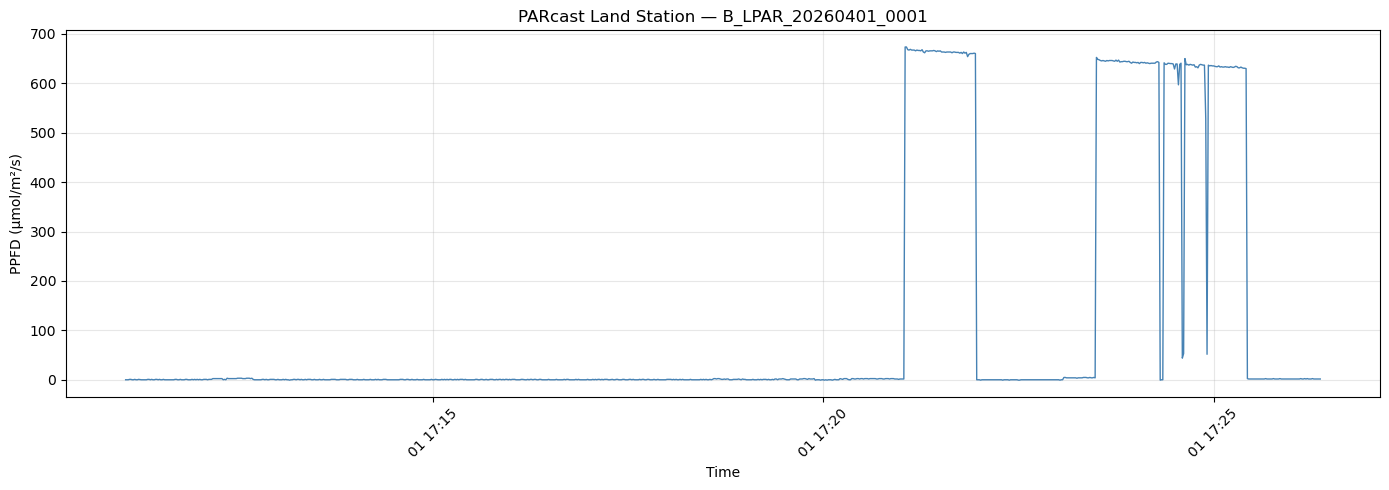

In [6]:
# Plot PPFD over time
plt.figure(figsize=(14, 5))
plt.plot(df['datetime'], df['ppfd_umol_m2_s'], color='steelblue', linewidth=1)
plt.xlabel('Time')
plt.ylabel('PPFD (µmol/m²/s)')
plt.title('PARcast Land Station — B_LPAR_20260401_0001')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


17:11 - 17:23 — flat near zero, sensor indoors with cap on

17:23 — sharp jump to ~660 µmol/m²/s,  went outside

17:23 - 17:21 — steady outdoor readings ~640-660

The dips — people walking by and hand waving

17:25 — drops back to zero, cap back on

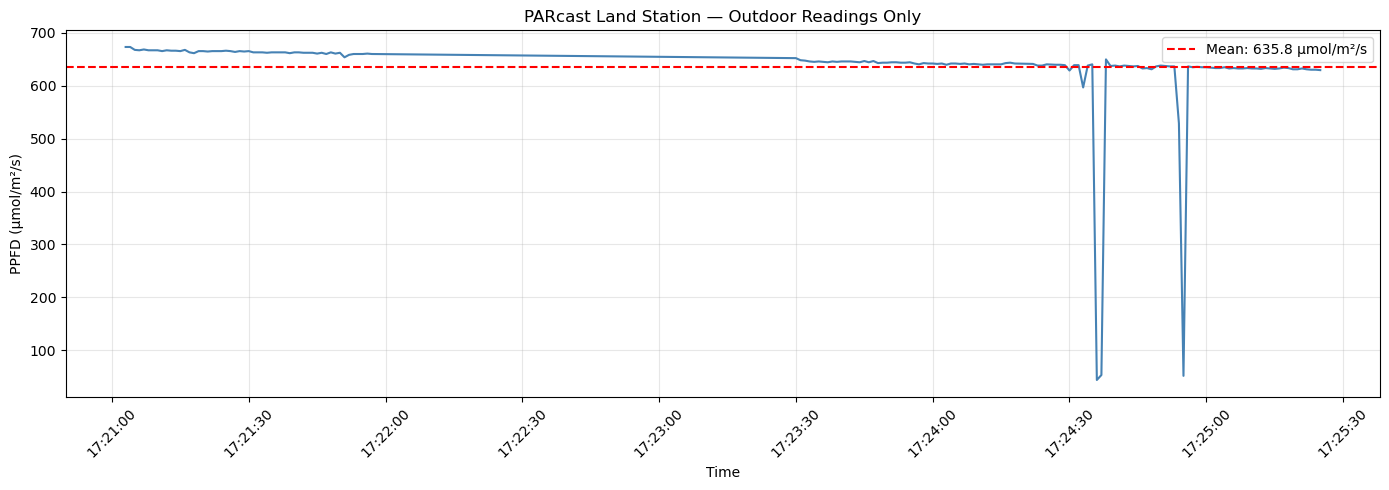

In [7]:
# Filter to only show outdoor readings (PPFD > 10)
df_outdoor = df[df['ppfd_umol_m2_s'] > 10]

plt.figure(figsize=(14, 5))
plt.plot(df_outdoor['datetime'], df_outdoor['ppfd_umol_m2_s'], 
         color='steelblue', linewidth=1.5)
plt.xlabel('Time')
plt.ylabel('PPFD (µmol/m²/s)')
plt.title('PARcast Land Station — Outdoor Readings Only')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add mean line
mean_ppfd = df_outdoor['ppfd_umol_m2_s'].mean()
plt.axhline(y=mean_ppfd, color='red', linestyle='--', 
            label=f'Mean: {mean_ppfd:.1f} µmol/m²/s')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Summary statistics for outdoor readings only
print("=== PARcast Land Station Summary ===")
print(f"File: B_LPAR_20260401_0001.CSV")
print(f"Deployment start: {df['datetime'].min()}")
print(f"Deployment end:   {df['datetime'].max()}")
print(f"Total readings:   {len(df)}")
print(f"Outdoor readings: {len(df_outdoor)}")
print(f"Mean PPFD:        {df_outdoor['ppfd_umol_m2_s'].mean():.1f} µmol/m²/s")
print(f"Max PPFD:         {df_outdoor['ppfd_umol_m2_s'].max():.1f} µmol/m²/s")
print(f"Min PPFD:         {df_outdoor['ppfd_umol_m2_s'].min():.1f} µmol/m²/s")
print(f"Std deviation:    {df_outdoor['ppfd_umol_m2_s'].std():.1f} µmol/m²/s")

=== PARcast Land Station Summary ===
File: B_LPAR_20260401_0001.CSV
Deployment start: 2026-04-01 17:11:04
Deployment end:   2026-04-01 17:26:22
Total readings:   906
Outdoor readings: 166
Mean PPFD:        635.8 µmol/m²/s
Max PPFD:         673.4 µmol/m²/s
Min PPFD:         43.8 µmol/m²/s
Std deviation:    81.4 µmol/m²/s
